### **Load the data**

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np
from scipy import stats

In [5]:
df= pd.read_csv(r"C:\courses\Data_Sceince_Courses\time_series\air_quality_project\data\processed.csv")
print(df.head())


              timestamp       pm25
0  2025-07-25T10:00:00Z  26.997652
1  2025-07-25T11:00:00Z  23.385417
2  2025-07-25T12:00:00Z        NaN
3  2025-07-25T13:00:00Z  30.693000
4  2025-07-25T14:00:00Z  23.904379


- ### **Handling Missing Data**

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1058 entries, 0 to 1057
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  1058 non-null   object 
 1   pm25       1000 non-null   float64
dtypes: float64(1), object(1)
memory usage: 16.7+ KB


In [8]:
df.isna().sum()

timestamp     0
pm25         58
dtype: int64

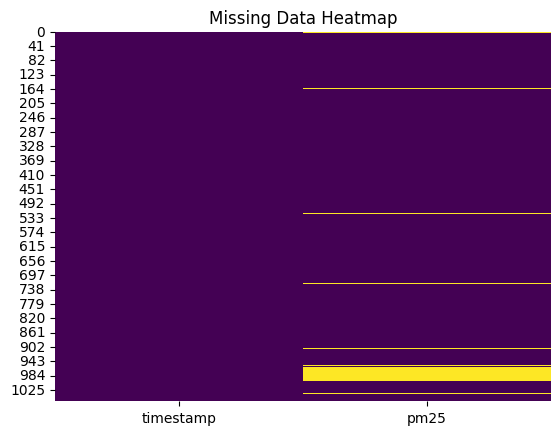

In [10]:
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Data Heatmap")
plt.show()

- **Time-Aware Interpolation**

In [11]:
# Time-aware interpolation: set datetime index, ensure hourly index, interpolate by time
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
df = df.sort_values('timestamp').set_index('timestamp')

full_idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq='H', tz=df.index.tz)
df = df.reindex(full_idx)

df['pm25_interpolated'] = df['pm25'].interpolate(method='time')
df['pm25_interpolated'] = df['pm25_interpolated'].ffill().bfill()

df.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_8908\2249257307.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  full_idx = pd.date_range(start=df.index.min(), end=df.index.max(), freq='H', tz=df.index.tz)


,pm25,pm25_interpolated
2025-07-25 10:00:00+00:00,26.997652,26.997652
2025-07-25 11:00:00+00:00,23.385417,23.385417
2025-07-25 12:00:00+00:00,NaN,27.039208
2025-07-25 13:00:00+00:00,30.693000,30.693000
2025-07-25 14:00:00+00:00,23.904379,23.904379


### **What is Stationary**
  A time series data with constant
- Mean , Variance and autocrelation through timr

- #### **Visualize the interpolated data**

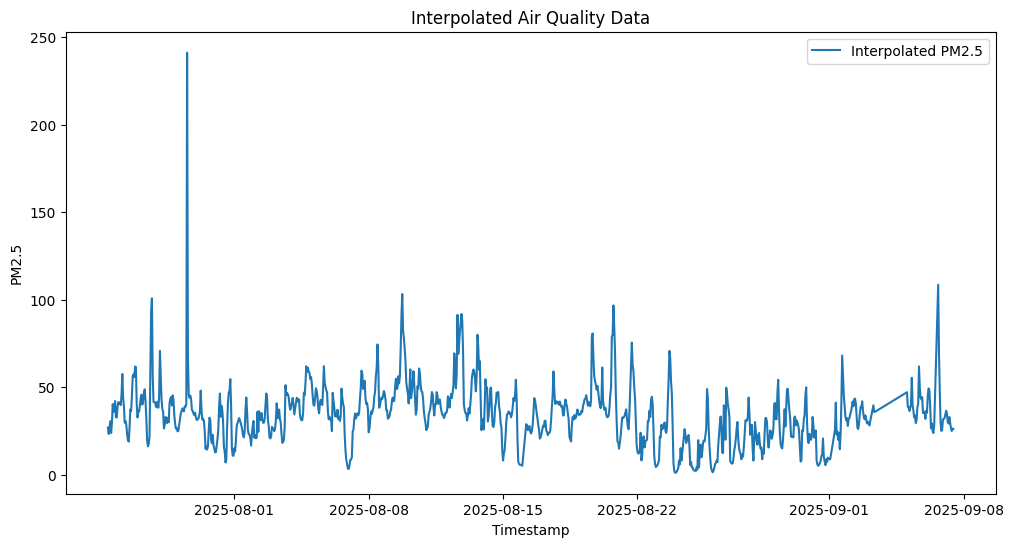

In [13]:

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['pm25_interpolated'], label='Interpolated PM2.5')
plt.xlabel('Timestamp')
plt.ylabel('PM2.5')
plt.title('Interpolated Air Quality Data')
plt.legend()
plt.show()

In [15]:
def plotting ():
    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df['pm25_interpolated'], label='Interpolated PM2.5')
    plt.xlabel('Timestamp')
    plt.ylabel('PM2.5')
    plt.title('Interpolated Air Quality Data')
    plt.legend()
    plt.show()

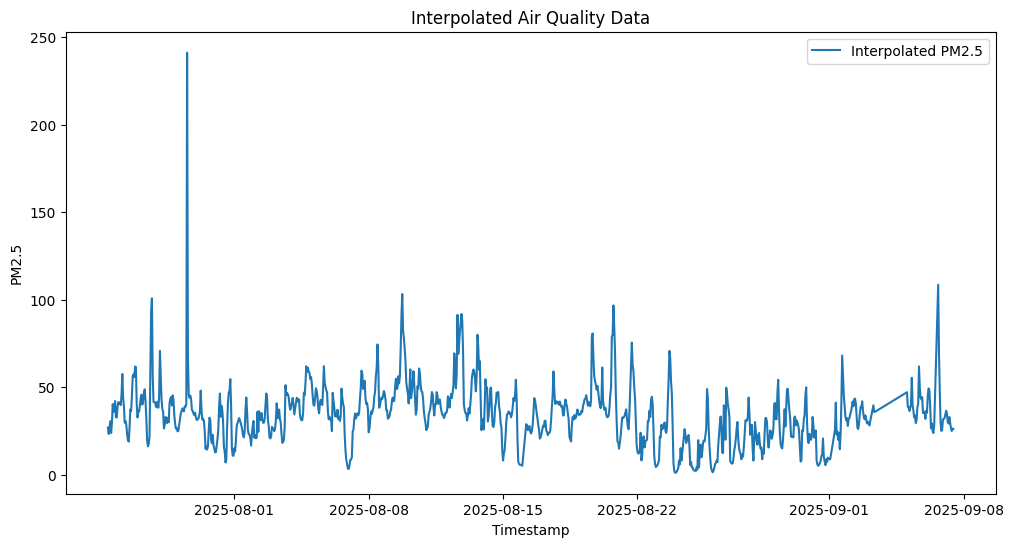

In [16]:
plotting()

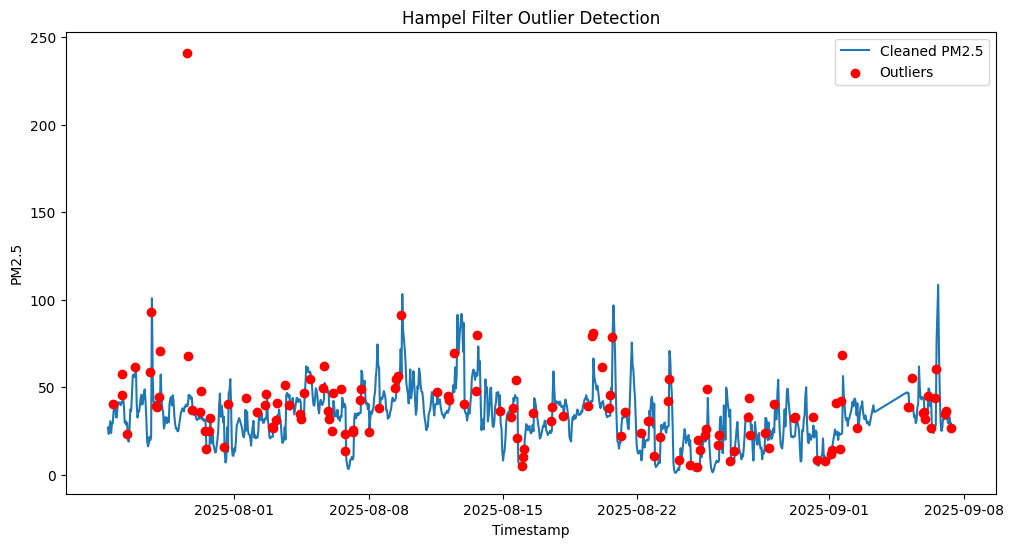

In [17]:
from scipy.stats import median_abs_deviation


def hampel_filter(series, window_size=5, n_sigmas=3):
    """Detects and replaces outliers using rolling median and MAD."""
    # Step 1: Compute rolling median
    rolling_median = series.rolling(window=window_size, min_periods=1).median()

    # Step 2: Compute rolling Median Absolute Deviation (MAD)
    def c_mad(x):
        return median_abs_deviation(x, scale="normal")

    rolling_mad = (
        series.rolling(window=window_size, min_periods=1).apply(c_mad).fillna(0)
    )

    # Step 3: Find points that exceed threshold
    threshold = n_sigmas * rolling_mad
    difference = (series - rolling_median).abs()
    outlier_mask = difference > threshold

    # Step 4: Clean the data by replacing outliers with rolling median
    cleaned_series = series.copy()
    cleaned_series[outlier_mask] = rolling_median[outlier_mask]

    return cleaned_series, outlier_mask

df_outliers = df.copy()
df_outliers['pm25_cleaned'], outliers = hampel_filter(df_outliers['pm25_interpolated']) 
plt.figure(figsize=(12, 6))
plt.plot(df_outliers.index, df_outliers['pm25_cleaned'], label='Cleaned PM2.5')
plt.scatter(df_outliers.index[outliers], df_outliers['pm25_interpolated'][outliers], color='red', label='Outliers', zorder=5)
plt.xlabel('Timestamp') 
plt.ylabel('PM2.5')
plt.title('Hampel Filter Outlier Detection')
plt.legend()

In [18]:
df.describe()

,pm25,pm25_interpolated
count,1000.000000,1058.000000
mean,34.286123,34.532825
std,17.347660,17.173767
min,1.236542,1.236542
25%,24.594510,24.772875
50%,33.940979,34.413333
75%,42.466927,42.735037
max,241.195004,241.195004


In [20]:
df_outliers['pm25_cleaned'].describe()

count    1058.000000
mean       33.588294
std        15.463784
min         1.236542
25%        24.094854
50%        33.789521
75%        42.048406
max       108.634446
Name: pm25_cleaned, dtype: float64

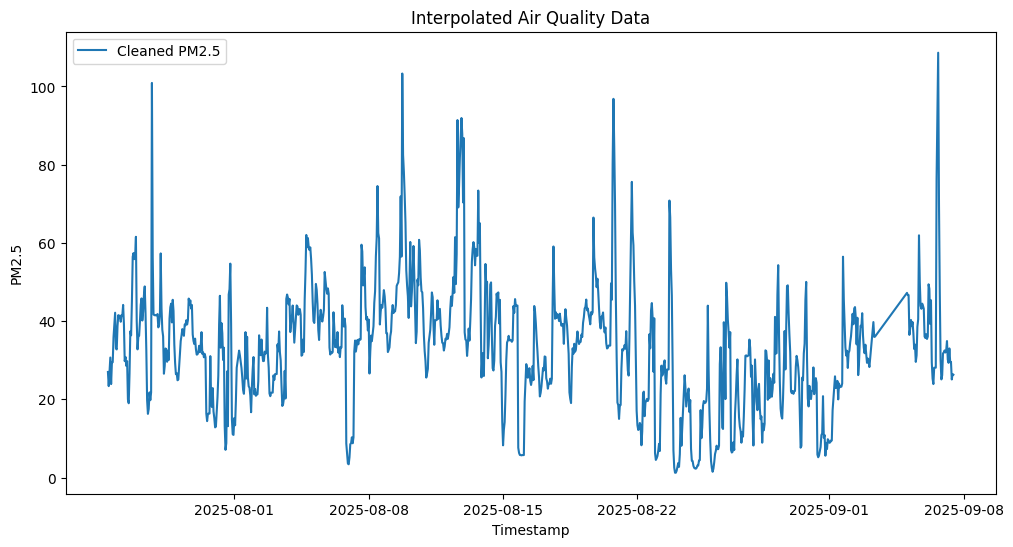

In [21]:

plt.figure(figsize=(12, 6))
plt.plot(df.index, df_outliers['pm25_cleaned'], label='Cleaned PM2.5')
plt.xlabel('Timestamp')
plt.ylabel('PM2.5')
plt.title('Interpolated Air Quality Data')
plt.legend()
plt.show()

- As we can see from the plot the timeseries data seems stationary but lets do better.

1. **Differencing**
  
  - d(t)= y(t)-y(t-1)

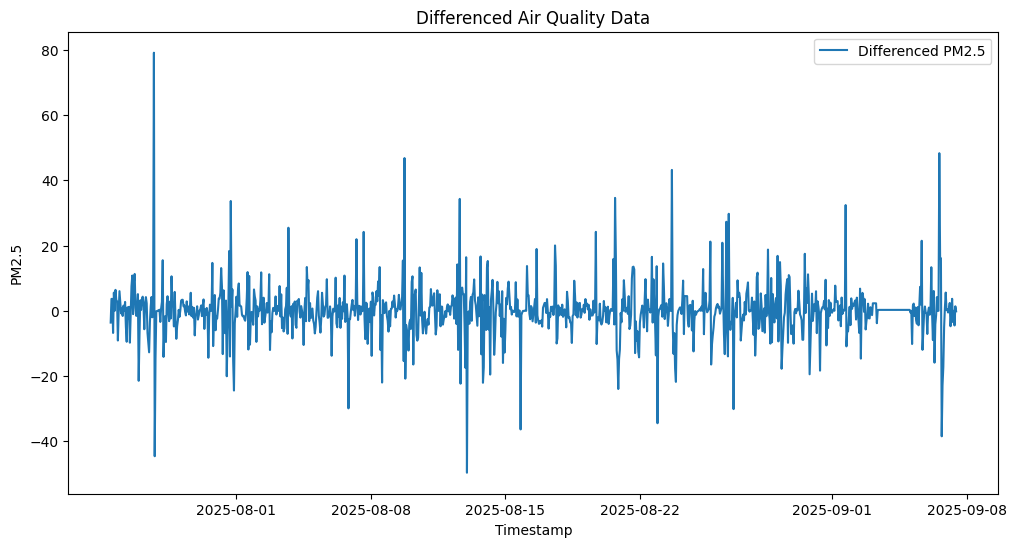

In [22]:
#take the difference  it d(t)= y(t)-y(t-1) for making stationary and plot
df_outliers['pm25_diff'] = df_outliers['pm25_cleaned'].diff() 
plt.figure(figsize=(12, 6))
plt.plot(df_outliers.index, df_outliers['pm25_diff'], label='Differenced PM2.5')
plt.xlabel('Timestamp') 
plt.ylabel('PM2.5')
plt.title('Differenced Air Quality Data')
plt.legend()
plt.show()  


- **Now the mean is zero which constant through time but variance ..ehmmm**

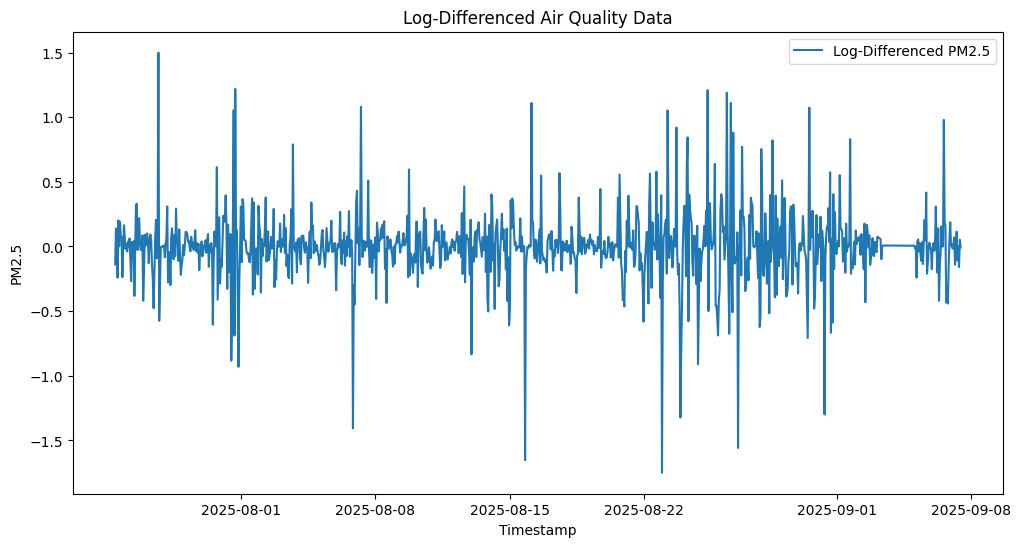

In [28]:
# Logarithmic transformation and differencing to stabilize variance 
df_outliers['pm25_log'] = np.log(df_outliers['pm25_cleaned'] + 1)  # Add 1 to avoid log(0)
df_outliers['pm25_log_diff'] = df_outliers['pm25_log'].diff()
#plot the log-differenced data
plt.figure(figsize=(12, 6))
plt.plot(df_outliers.index, df_outliers['pm25_log_diff'], label='Log-Differenced PM2.5')
plt.xlabel('Timestamp')
plt.ylabel('PM2.5')
plt.title('Log-Differenced Air Quality Data')
plt.legend()
plt.show()

In [29]:
# Stationary test- ADF test
from statsmodels.tsa.stattools import adfuller
result = adfuller(df_outliers['pm25_log_diff'].dropna())
print('ADF Statistic:', result[0])
print('p-value:', result[1])


ADF Statistic: -11.939681224165778
p-value: 4.574168761016598e-22


**The Interpretation**
 - The \(p\)-value (\(4.57 \times 10^{-22}\)) is effectively zero. It is far below the standard significance threshold (\(\alpha = 0.05\)). You can confidently reject the null hypothesis of non-stationarity.The ADF Statistic (\(-11.94\)) is highly negative. This means your data strongly resists trends or random walks and constantly reverts to its mean.

#### **Handle Seasonal Differencing**

In [37]:
import pmdarima as pm

# The optimizer will find the best d value for you
auto_model = pm.auto_arima(
    df["pm25_interpolated"].dropna(),
    seasonal=True,
    m=24,
    stepwise=True,
    trace=True,  # This will print out the d value it chooses (e.g., d=1)
)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[24] intercept   : AIC=inf, Time=5.14 sec
 ARIMA(0,1,0)(0,0,0)[24] intercept   : AIC=8107.630, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[24] intercept   : AIC=8082.511, Time=0.46 sec
 ARIMA(0,1,1)(0,0,1)[24] intercept   : AIC=8078.001, Time=0.57 sec
 ARIMA(0,1,0)(0,0,0)[24]             : AIC=8105.630, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[24] intercept   : AIC=8086.655, Time=0.09 sec
 ARIMA(0,1,1)(1,0,1)[24] intercept   : AIC=inf, Time=2.32 sec
 ARIMA(0,1,1)(0,0,2)[24] intercept   : AIC=8078.868, Time=3.29 sec
 ARIMA(0,1,1)(1,0,0)[24] intercept   : AIC=8077.197, Time=0.72 sec
 ARIMA(0,1,1)(2,0,0)[24] intercept   : AIC=8077.687, Time=3.50 sec
 ARIMA(0,1,1)(2,0,1)[24] intercept   : AIC=inf, Time=10.31 sec
 ARIMA(0,1,0)(1,0,0)[24] intercept   : AIC=8102.246, Time=0.56 sec
 ARIMA(1,1,1)(1,0,0)[24] intercept   : AIC=7972.681, Time=1.74 sec
 ARIMA(1,1,1)(0,0,0)[24] intercept   : AIC=7984.362, Time=0.21 sec
 ARIMA(1,1,1)(2,0,0)[24] intercep

MemoryError: Unable to allocate 5.46 MiB for an array with shape (26, 26, 1059) and data type float64